In [5]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

In [7]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils    import to_categorical
from tensorflow.keras.models   import Sequential, save_model, load_model
from tensorflow.keras.layers   import Input, Conv2D, MaxPool2D, Flatten, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix

In [7]:
 # 1.데이터 셋
width = 28; height=28
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train.shape, y_train.shape, X_test.shape, y_test.shape


((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

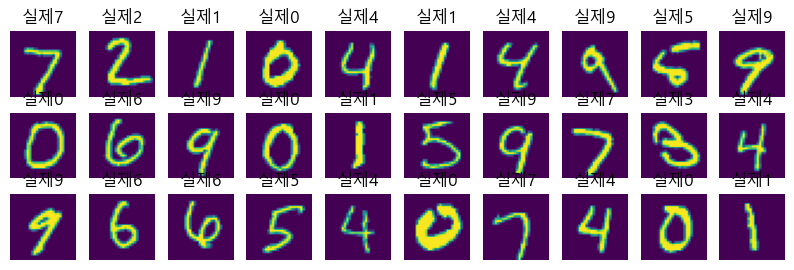

In [12]:
plt_row = 3
plt_col = 10
plt.rcParams['figure.figsize'] = [plt_col, plt_row]
plt.rc("font", family="Malgun Gothic")
fig, axes = plt.subplots(plt_row, plt_col)
'''axes[0, 0].imshow(X_test[0].reshape(width, height))
axes[0, 0].axis('off')
title = '실제:{}'.format(y_test[0])
axes[0,0].set_title(title)
'''
for i in range(plt_row*plt_col):
    subax = axes[i//plt_col, i%plt_col]
    subax.imshow(X_test[i].reshape(width, height))
    subax.axis('off')
    title = '실제{}'.format(y_test[i])
    subax.set_title(title)

## 1. DNN

In [ ]:
# 1. 데이터 생성 및 전처리

In [4]:
width=28; height=28
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
# 독립변수 (28,28) => 784 1차원 -> 실수형변환 -> 스케일 조정
X_train = X_train.reshape(-1, width*height).astype('float')/255.0
X_val = X_val.reshape(-1, width*height).astype('float')/255.0
X_test = X_test.reshape(-1, width*height).astype('float')/255.0
# 타겟변수 원핫인코딩
Y_train = to_categorical(y_train)
Y_val = to_categorical(y_val)
Y_test = to_categorical(y_test)
X_train.shape, Y_train.shape, X_val.shape, Y_val.shape, X_test.shape, Y_test.shape

((50000, 784),
 (50000, 10),
 (10000, 784),
 (10000, 10),
 (10000, 784),
 (10000, 10))

In [24]:
#2 모델구성
model = Sequential([
    Input(shape=(width*height,)),
    Dense(1024, activation='relu'),
    Dropout(0.3),
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax')
])
model.compile(loss='categorical_crossentropy',
                     optimizer='adam',
                     metrics=['accuracy'])

model.fit(X_train, Y_train,
         epochs=50,
         validation_data=(X_val, Y_val),
         verbose=1)

Epoch 1/50
1563/1563 [==============================] - 19s 12ms/step - loss: 0.2613 - accuracy: 0.9206 - val_loss: 0.1140 - val_accuracy: 0.9659
Epoch 2/50
1563/1563 [==============================] - 18s 11ms/step - loss: 0.1351 - accuracy: 0.9603 - val_loss: 0.0961 - val_accuracy: 0.9707
Epoch 3/50
1563/1563 [==============================] - 18s 11ms/step - loss: 0.1025 - accuracy: 0.9693 - val_loss: 0.0947 - val_accuracy: 0.9723
Epoch 4/50
1563/1563 [==============================] - 18s 11ms/step - loss: 0.0874 - accuracy: 0.9737 - val_loss: 0.0885 - val_accuracy: 0.9771
Epoch 5/50
1563/1563 [==============================] - 18s 12ms/step - loss: 0.0808 - accuracy: 0.9754 - val_loss: 0.0909 - val_accuracy: 0.9761
Epoch 6/50
1563/1563 [==============================] - 18s 12ms/step - loss: 0.0681 - accuracy: 0.9799 - val_loss: 0.0847 - val_accuracy: 0.9779
Epoch 7/50
1563/1563 [==============================] - 18s 12ms/step - loss: 0.0649 - accuracy: 0.9803 - val_loss: 0.0871 -

In [28]:
# 혼동행렬
from sklearn.metrics import confusion_matrix
print(y_test)
print(np.argmax(Y_test, axis=1))
# 모델 예측
yhat = model.predict(X_test)  # X_test는 (샘플 수, feature 크기) 형태여야 합니다.
yhat = np.argmax(yhat, axis=1)  # 예측된 결과를 정수 레이블로 변환

# 실제 y_test는 정수 형태일 때
cmatrix = confusion_matrix(y_test, yhat)
print(cmatrix)


[7 2 1 ... 4 5 6]
[7 2 1 ... 4 5 6]
313/313 [==============================] - 1s 4ms/step
[[ 972    1    0    1    1    1    2    1    1    0]
 [   0 1125    1    2    0    0    3    2    2    0]
 [   6    0 1012    1    1    0    3    5    3    1]
 [   0    0    4  990    0    5    0    6    2    3]
 [   2    0    1    0  963    0    5    3    0    8]
 [   3    0    0    9    0  862    8    1    2    7]
 [   5    3    0    0    3    1  944    0    2    0]
 [   2    0    8    2    0    0    0 1010    2    4]
 [   1    0    1    2    2    3    3    3  957    2]
 [   1    2    1    0    5    0    0    5    3  992]]


In [30]:
# 실제값과 예측값이 다른 갯수
cnt = 0
for y, h in zip(y_test, yhat):
    if y!=h:
        cnt += 1
print(cnt)

173


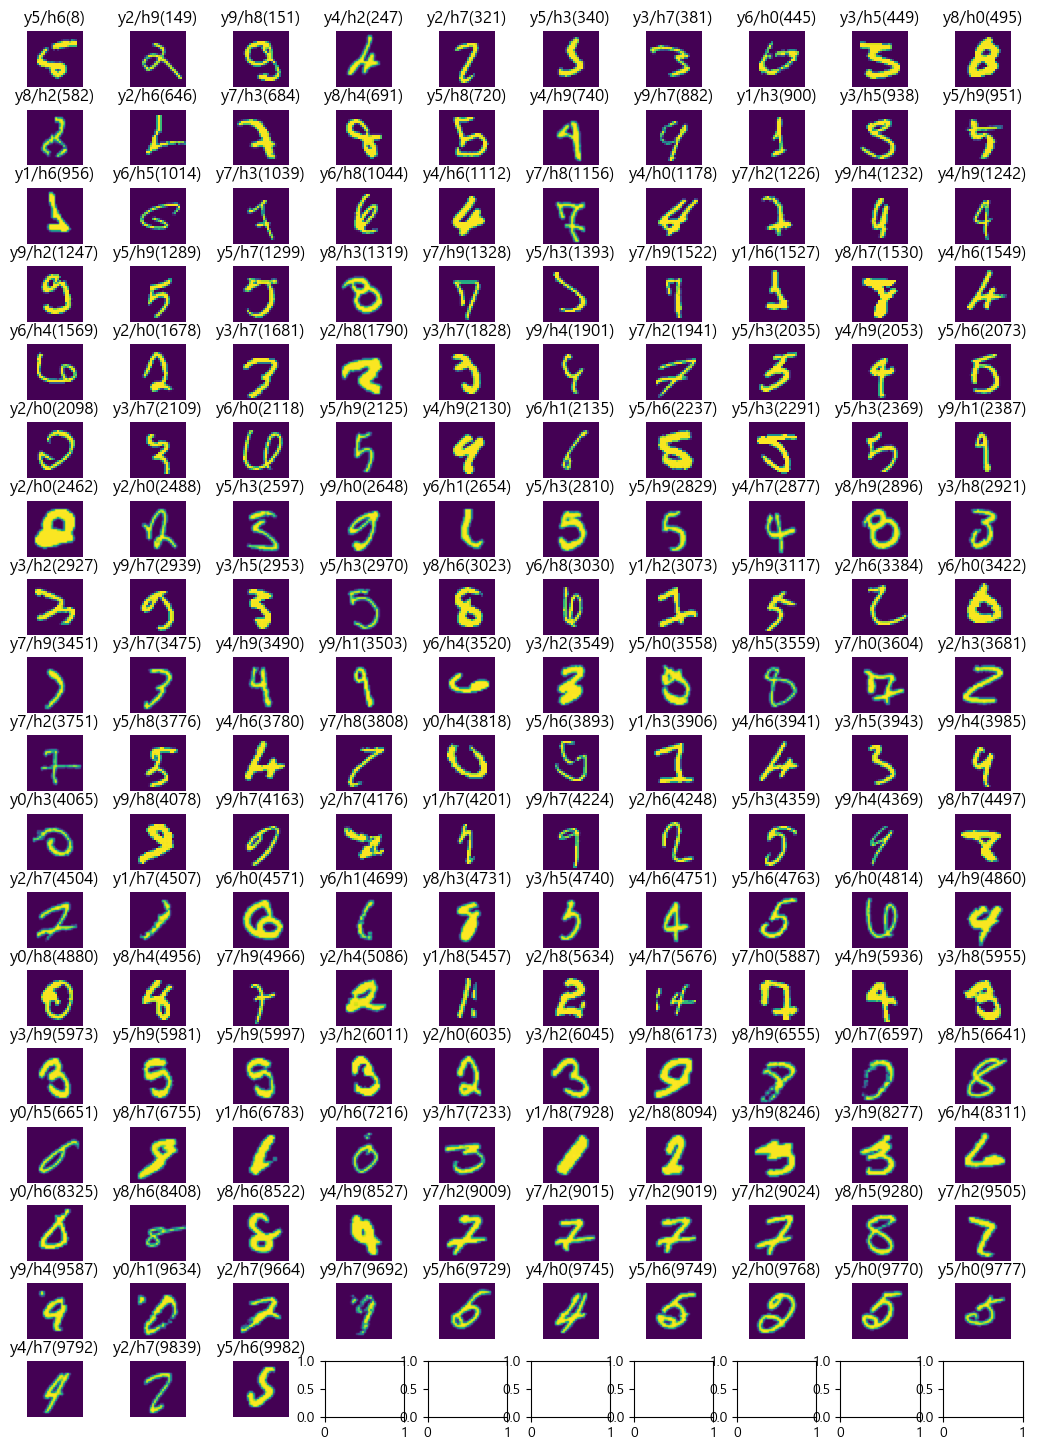

In [32]:
# CNN을 사용하여 예측이 틀린 데이터 출력(yhat과 y_test가 다른 것들 172개)
plt_row = 18
plt_col = 10
plt.rcParams['figure.figsize'] = [plt_col+3, plt_row]
plt.rc("font", family="Malgun Gothic") # window에서 한글 시각화
# plt.rc("font", family="NanumBarunGothic") # 코랩에서 한글 시각화
fig, axes = plt.subplots(plt_row, plt_col)
plt.subplots_adjust(hspace=0.4, wspace=0.3)

i=0 # yhat과 y_test의 index => yhat[i], y_test[i]를 비교. 
cnt=0 # 이미지 출력횟수

while (i<len(y_test)) & (cnt < plt_row*plt_col):
    if yhat[i] == y_test[i]:
        i += 1
        continue
    subax = axes[cnt//plt_col, cnt%plt_col] # //:몫연산자 %:나머지연산자
    subax.imshow(X_test[i].reshape(width, height))
    subax.axis('off')
    title = "y{}/h{}({})".format(y_test[i], yhat[i], i)
    subax.set_title(title)
    cnt += 1 # 이미지 출력 번호 증가
    i += 1 # index 증가
#plt.tight_layout()

# cnn 

In [8]:
# 1. 데이터 생성 및 전처리
width=28; height=28
(X_train, y_train), (X_test, y_test)= mnist.load_data()
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
# 독립변수 (28,28) => 784 1차원 -> 실수형변환 -> 스케일조정
X_train = X_train.reshape(-1, width*height).astype('float32')/255.0
X_val = X_val.reshape(-1, width*height).astype('float32')/255.0
X_test = X_test.reshape(-1, width*height).astype('float32')/255.0
# 타겟변수 원핫인코딩
Y_train = to_categorical(y_train)
Y_val = to_categorical(y_val)
Y_test = to_categorical(y_test)

X_train.shape, Y_train.shape, X_val.shape, Y_val.shape, X_test.shape, Y_test.shape

((50000, 784),
 (50000, 10),
 (10000, 784),
 (10000, 10),
 (10000, 784),
 (10000, 10))

In [10]:
# 2. 모델생성
model = Sequential()
model.add(Conv2D(filters=32, #  필터수
                 kernel_size=3,# 필터사이즈 (3,3)
                 padding='same', # zero-padding을 하면 출력사이즈도 동일
                 input_shape=(width, height, 1), # 입력채널1개, 필터32 => 28*28*32채널 출력
                 activation='relu'
                ))
model.add(MaxPool2D(pool_size=(2,2))) # => 14*14*32
model.add(Dropout(0.1))
model.add(Conv2D(64, (3,3), activation='relu')) #=> ((14-3+1)*(14-3+1)*32 ) *64
model.add(MaxPool2D(pool_size=(2,2))) #=> 6*6
model.add(Dropout(0.25))
model.add(Flatten()) # 입력을 1차원으로 
model.add(Dense(units=128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(units=10, activation='softmax'))
model.summary()
# 320 => 3x3 필터가 weight ( 9+1(bias)) *32개 필터


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 14, 14, 32)       0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 14, 14, 32)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 12, 12, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 6, 6, 64)         0         
 2D)                                                             
                                                                 
 dropout_1 (Dropout)         (None, 6, 6, 64)         

NameError: name 'hist' is not defined

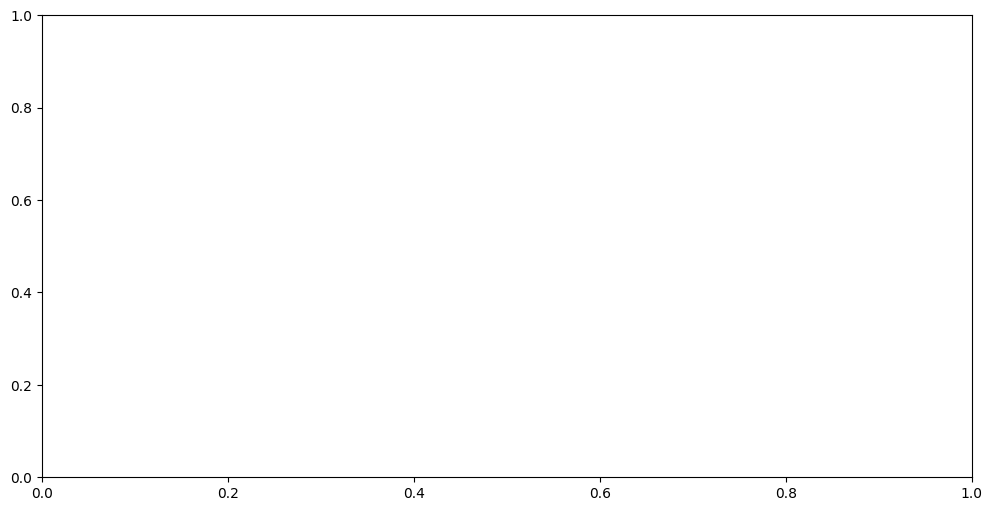